In [1]:
import numpy as np
import random as rn
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow
import os, json

# Custom Settings
from convex_map import generate_map
from heatmap_animation import generate_heatmap


In [2]:
# Operation Map Visualization
def _bounce_angle(theta0: float, bound_plus: float, bound_minus: float, panspeed: float, t: float) -> float:
    """
    Bounce-pan angle inside [theta0+bound_minus, theta0+bound_plus] at time t.
    Angles are radians; panspeed is rad per unit time.
    """
    lo = theta0 + float(bound_minus)
    hi = theta0 + float(bound_plus)
    if lo > hi:
        lo, hi = hi, lo
    span = hi - lo
    if span <= 1e-12 or abs(panspeed) <= 1e-12:
        return theta0
    raw = theta0 + panspeed * t
    period = 2.0 * span
    off = (raw - lo) % period
    return (lo + off) if (off <= span) else (hi - (off - span))

def visualize_map_at_time(map_in, cam_dict, t: float, sensor_alpha: float = 0.5, ax=None):
    """
    Visualize the operation map at time t using your schema.

    Args:
        map_in: dict with 'st': {'size': [xmin,xmax,ymin,ymax], 'n': int, '0': poly0, ...}
        cam_dict: dict with 'n', 'x', 'y', and 'spec' fields:
            - spec['init_angle'] : list of radians
            - spec['bound']      : array-like shape (n, 2) = [ [ +max, -max ], ... ]
            - spec['fov']        : [ half_angle_rad, range ]
            - spec['cam_time']   : [ cam_period, cam_increment ]  (not required here)
            - spec['panspeed']   : list of rad/time
        t: time (same units as your panspeed / cam_time increment)
        sensor_alpha: alpha for the green FOV wedges
        ax: optional matplotlib Axes; if None, a new figure/axes is created

    Returns:
        fig, ax
    """
    # ---- Static map bounds & buildings ----
    st = map_in["st"]
    size = np.array(st["size"], dtype=float)   # [xmin, xmax, ymin, ymax]
    xmin, xmax, ymin, ymax = size

    buildings = []
    for i in range(st["n"]):
        poly = np.array(st[str(i)], dtype=float)
        buildings.append(poly)

    # ---- Cameras & spec ----
    cx = np.array(cam_dict["x"], dtype=float)
    cy = np.array(cam_dict["y"], dtype=float)
    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)          # radians
    bound_arr = np.array(spec["bound"], dtype=float)                 # (n,2) = [+max, -max]
    fov_half = float(spec["fov"][0])                                 # radians
    fov_range = float(spec["fov"][1])                                # map units
    panspeeds = np.array(spec["panspeed"], dtype=float)              # rad/time

    # Compute facing angles at time t with bounce pan
    facings = np.array([
        _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
        for i in range(len(cx))
    ], dtype=float)

    # ---- Plot ----
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    # Buildings: black
    for poly in buildings:
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

    # Sensors: green circles
    ax.scatter(cx, cy, s=36, c="green", marker="o", zorder=3, label="sensors")

    # FOV wedges: green with alpha
    for i in range(len(cx)):
        theta_deg = math.degrees(facings[i])
        wedge = Wedge(
            center=(cx[i], cy[i]),
            r=fov_range,
            theta1=theta_deg - math.degrees(fov_half),
            theta2=theta_deg + math.degrees(fov_half),
            facecolor="green",
            edgecolor=None,
            alpha=float(sensor_alpha),
            zorder=2
        )
        ax.add_patch(wedge)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Operation Map @ t = {t:.2f}")
    return fig, ax


In [3]:
from matplotlib.animation import FuncAnimation, writers

def _bounce_angle(theta0: float, bound_plus: float, bound_minus: float, panspeed: float, t: float) -> float:
    """Bounce-pan angle inside [theta0+bound_minus, theta0+bound_plus] at time t (radians)."""
    lo = theta0 + float(bound_minus)
    hi = theta0 + float(bound_plus)
    if lo > hi:
        lo, hi = hi, lo
    span = hi - lo
    if span <= 1e-12 or abs(panspeed) <= 1e-12:
        return theta0
    raw = theta0 + panspeed * t
    period = 2.0 * span
    off = (raw - lo) % period
    return (lo + off) if (off <= span) else (hi - (off - span))

def animate_camera_rotation(
    map_in: dict,
    cam_dict: dict,
    t_start: float = 0.0,
    t_end: float = 100.0,
    frame_interval: float = None,  # interval of frames
    dt_override: float = None,     # set to e.g. 0.1 for smoother playback; default uses spec['cam_time'][1]
    sensor_alpha: float = 0.5,
    save_path: str = None,          # e.g., "cams.mp4" or "cams.gif"
    desired_fps: int=24
):
    """
    Animate camera rotation over time using your map_in/cam_dict schema.

    Args:
        map_in: dict with 'st': {'size':[xmin,xmax,ymin,ymax], 'n': int, '0': poly0, ...}
        cam_dict: dict with 'n','x','y','spec' (init_angle, bound, fov, cam_time, panspeed)
        t_start, t_end: time window (seconds, or whatever units your panspeed uses)
        dt_override: if provided, overrides spec['cam_time'][1] for animation step
        sensor_alpha: FOV wedge alpha
        save_path: optional .mp4 or .gif

    Returns:
        (fig, anim)
    """
    # --- Static map & buildings ---
    st = map_in["st"]
    size = np.array(st["size"], dtype=float)  # [xmin, xmax, ymin, ymax]
    xmin, xmax, ymin, ymax = size
    buildings = [np.array(st[str(i)], dtype=float) for i in range(int(st["n"]))]

    # --- Cameras & spec ---
    cx = np.array(cam_dict["x"], dtype=float)
    cy = np.array(cam_dict["y"], dtype=float)
    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)
    bound_arr = np.array(spec["bound"], dtype=float)     # shape (n,2): [+max, -max]
    fov_half = float(spec["fov"][0])
    fov_range = float(spec["fov"][1])
    cam_period, cam_increment = int(spec["cam_time"][0]), float(spec["cam_time"][1])
    panspeeds = np.array(spec["panspeed"], dtype=float)

    dt = float(dt_override) if dt_override is not None else cam_increment
    t_vals = np.arange(t_start, t_end + 1e-9, dt)
    n_frames = len(t_vals)

    # --- Figure & static artists ---
    fig, ax = plt.subplots(figsize=(6, 6))
    # Buildings: black
    for poly in buildings:
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

    # Sensors: green circles
    ax.scatter(cx, cy, s=36, c="green", marker="o", zorder=3, label="sensors")

    # FOV wedges (one per sensor; we will update their angles)
    wedges: list[Wedge] = []
    for i in range(len(cx)):
        # initialize at t = t_start
        facing = _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t_vals[0])
        theta_deg = math.degrees(facing)
        w = Wedge(center=(cx[i], cy[i]),
                  r=fov_range,
                  theta1=theta_deg - math.degrees(fov_half),
                  theta2=theta_deg + math.degrees(fov_half),
                  facecolor="green",
                  edgecolor=None,
                  alpha=float(sensor_alpha),
                  zorder=2)
        ax.add_patch(w)
        wedges.append(w)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    # title = ax.set_title(f"Camera Rotation | t = {t_vals[0]:.2f}")

    # --- Update function ---
    def update(frame_idx: int):
        t = t_vals[frame_idx]
        for i, w in enumerate(wedges):
            facing = _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
            theta_deg = math.degrees(facing)
            w.set_theta1(theta_deg - math.degrees(fov_half))
            w.set_theta2(theta_deg + math.degrees(fov_half))
        # title.set_text(f"Camera Rotation | t = {t:.2f}")
        return wedges

    anim = FuncAnimation(fig, update, frames=n_frames, blit=True, interval=frame_interval)

    # Optional save
    if save_path:
        ext = save_path.lower().split(".")[-1]
        if ext == "mp4":
            try:
                Writer = writers["ffmpeg"]
                writer = Writer(fps=desired_fps, metadata=dict(artist="cams"), bitrate=2000)
                anim.save(save_path, writer=writer, dpi=150)
            except Exception as exc:
                print("FFMPEG not available or save failed:", exc)
        elif ext == "gif":
            try:
                anim.save(save_path, writer="pillow", dpi=150)
            except Exception as exc:
                print("GIF save failed:", exc)
        else:
            print("Unknown extension; not saved. Use .mp4 or .gif.")

    return fig, anim


In [4]:
# Run to Generate Map for Operation
map_in, cam_dict = generate_map(
    map_size = (50, 50),
    num_buildings = 2,
    num_sensors = 2,
    fov_half_rad = np.deg2rad(15),
    max_range = 20,
    panspeed_range = (np.deg2rad(-10), np.deg2rad(10)),
    cam_period = 200,
    cam_increment = 0.2,
    rng_seed = 11,
    balanced_sensors = False     # spread sensors across buildings
)


(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot:title={'center':'Operation Map @ t = 0.00'}>)

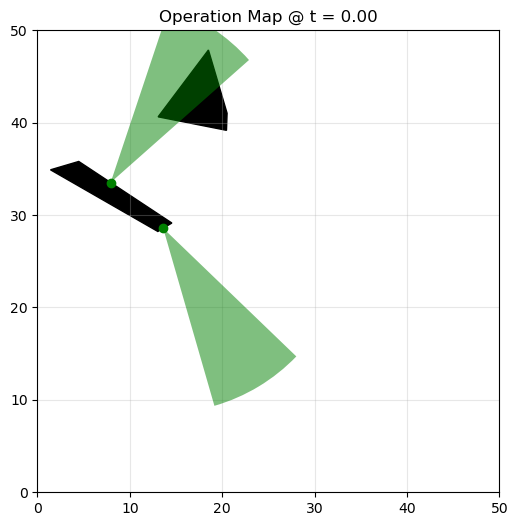

In [5]:
# Plot Map for Sanity Check
visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [6]:
generate_video_for_ao = False

if generate_video_for_ao:
    # Animate from 0 to 100 s using your cam_time increment
    # fig, anim = animate_camera_rotation(map_in, cam_dict, t_start=0.0, t_end=100.0, sensor_alpha=0.5)

    # …or smoother playback with a smaller dt:
    # fig, anim = animate_camera_rotation(map_in, cam_dict, t_start=0.0, t_end=100.0, dt_override=0.1, sensor_alpha=0.5)

    # …or save it:
    fig, anim = animate_camera_rotation(map_in, cam_dict, 0.0, 100.0, frame_interval=1, save_path="cams.mp4", desired_fps=50)


In [7]:
def make_json_serializable(obj):
    """
    Recursively convert numpy arrays in obj to lists,
    so it can be JSON-serialized.
    """
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_serializable(v) for v in obj]
    else:
        return obj

In [8]:
# Setup for STP-RRT*
x0 = [0, 0, 0]
xf = [0, 50, 100]
vmax = 5

stp_rrt_setup = {}
stp_rrt_setup['x0'] = x0
stp_rrt_setup['xf'] = xf
stp_rrt_setup['vmax'] = vmax

In [9]:
# Output into JSON file
# Full path to the file
file_path1 = os.path.join("json", "operation_map.json")
file_path2 = os.path.join("json", "defender_info.json")
file_path3 = os.path.join("json", "stp_rrt_setup.json")

# Write JSON file into that folder
with open(file_path1, "w") as f:
    json.dump(make_json_serializable(map_in), f, indent=4)

with open(file_path2, "w") as f:
    json.dump(make_json_serializable(cam_dict), f, indent=4)

with open(file_path3, "w") as f:
    json.dump(stp_rrt_setup, f, indent=4)

In [ ]:
adsfafsasf

NameError: name 'adsfafsasf' is not defined

Heatmap for PoD / Defender Asset Optimization

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 70
Iteration: 71
It

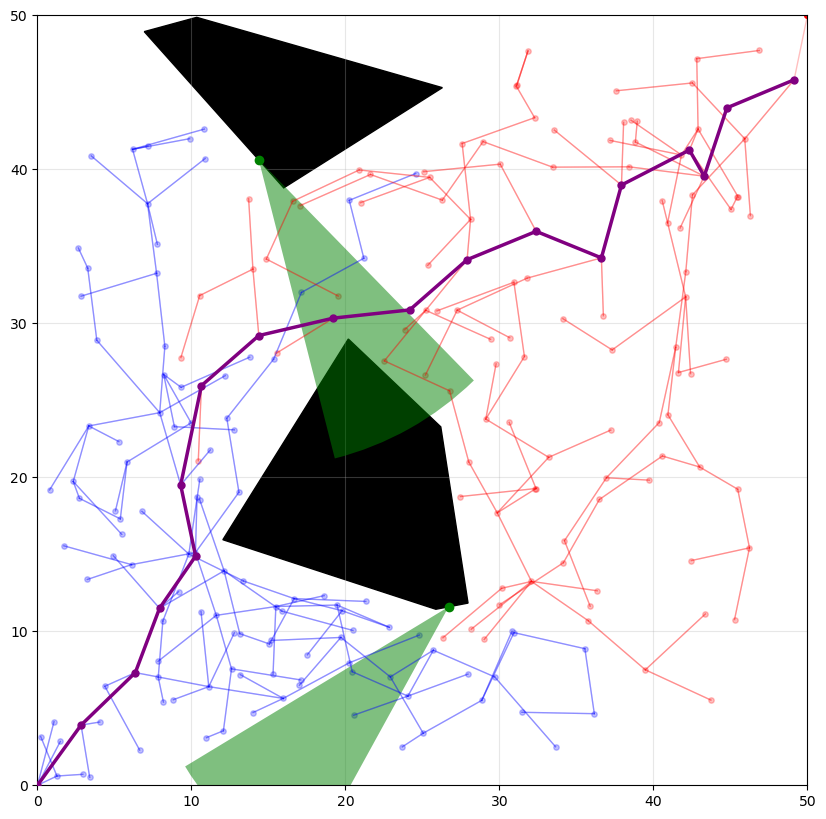

In [ ]:
# Run STP-RRT* Notebook:
%run ./stp_rrtstar.ipynb
# %run ./test.ipynb

In [ ]:
# Import results from STP-RRT*
file_path_stp_rrtstar = os.path.join("json", "stp_rrt_result.json")

with open(file_path_stp_rrtstar, "r") as f:
    stp_rrtstar_result = json.load(f)

# Parse Data:
stp_rrtstar_path = stp_rrtstar_result['path']
stp_rrtstar_Va = stp_rrtstar_result['vertex']['start_tree']
stp_rrtstar_Ea = stp_rrtstar_result['edge']['start_tree']
stp_rrtstar_Vb = stp_rrtstar_result['vertex']['goal_tree']
stp_rrtstar_Eb = stp_rrtstar_result['edge']['goal_tree']
stp_rrtstar_computation_time = stp_rrtstar_result['computation_time']
stp_rrtstar_distance_cost = stp_rrtstar_result['distance_cost ']
stp_rrtstar_time_cost = stp_rrtstar_result['time_cost ']

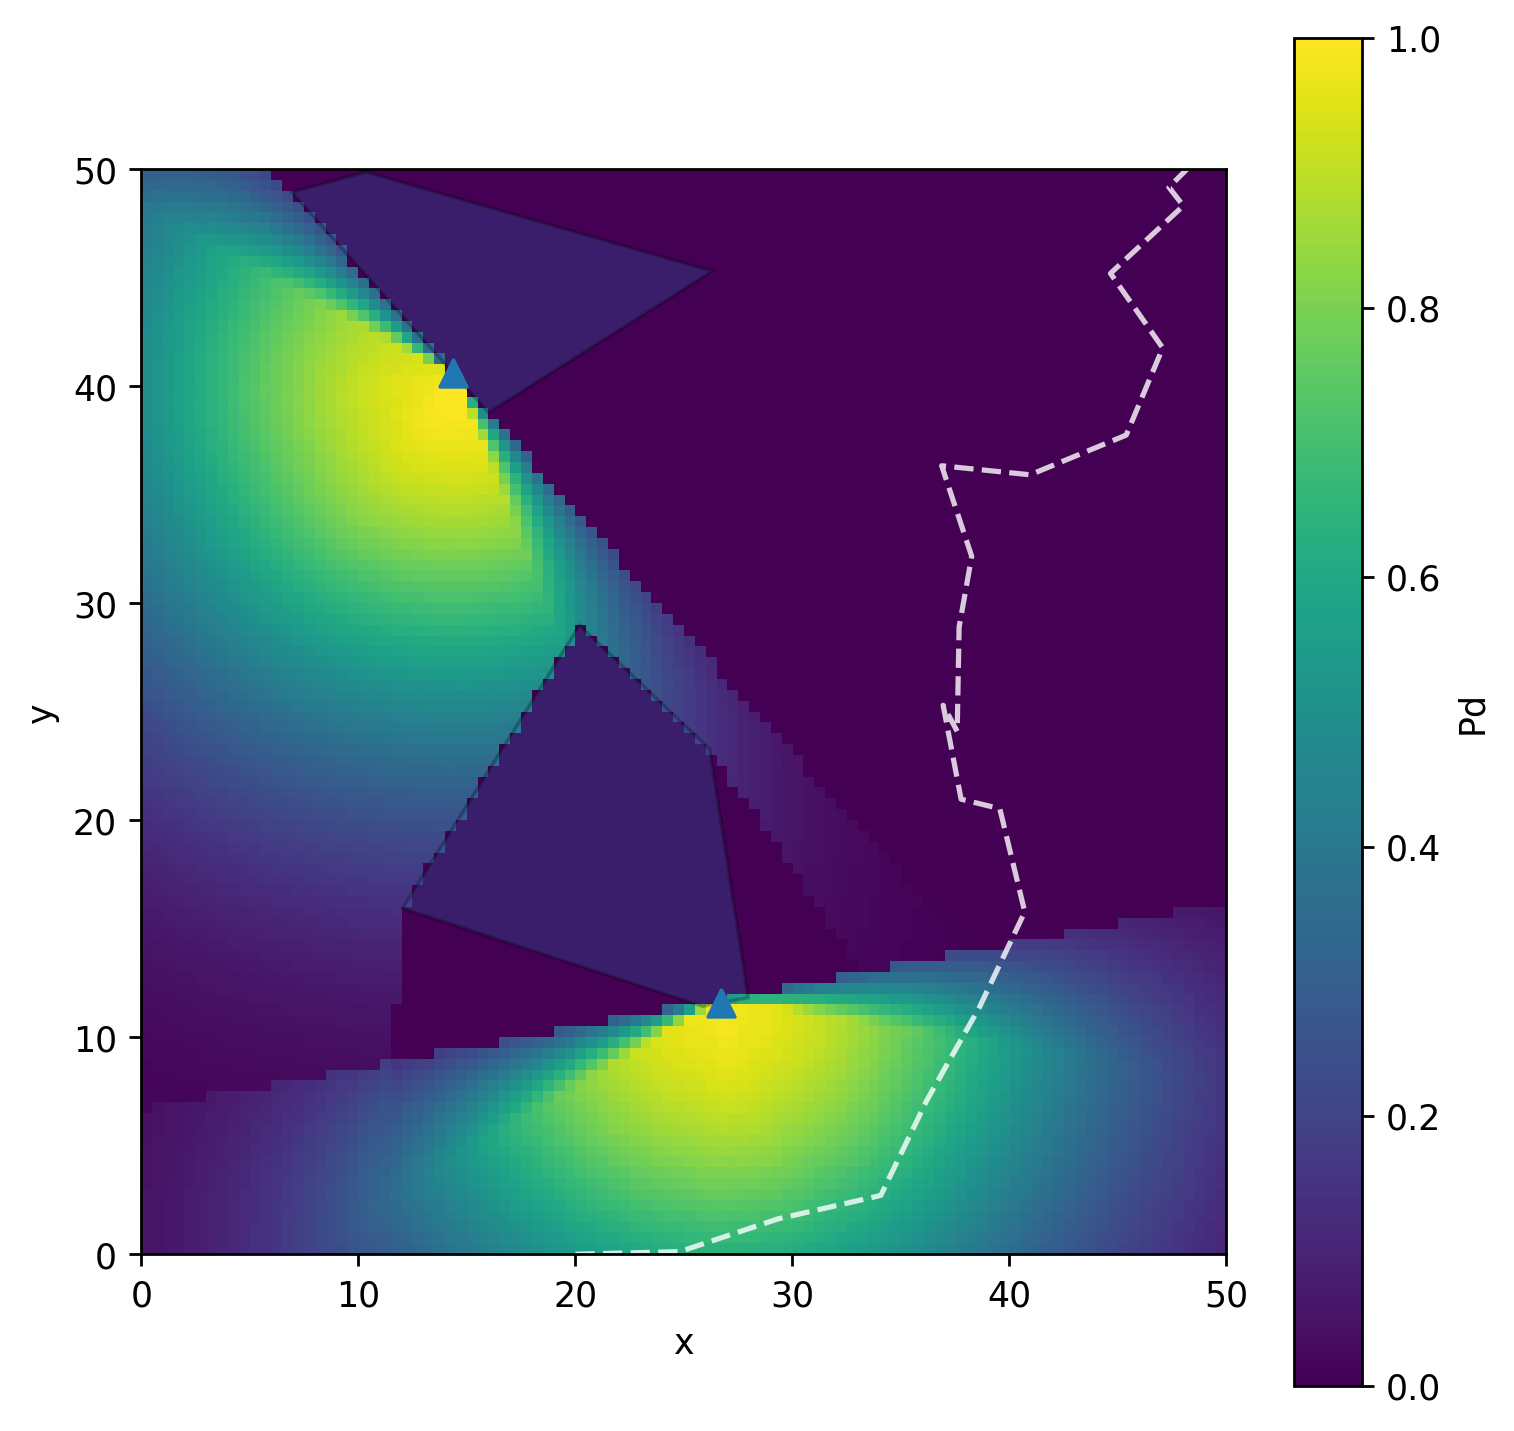

In [ ]:
# Display options:
# 1) normalize='minmax', display = 'mean': noramlized time-average
# 2) snapshot_t, normalize=None, display='snapshot': snapshot at t
# 3) normalize='minmax', compute_union=True, display='union': temproal-union

# Generate Animation
make_animation = False

# Generate snapshop heatmap at target time t
snapshot_heatmap = False
target_t = 10

# Generate time-average heatmap
time_average = True

# Generate heatmap for temporal union
temporal_union = False

##############
if make_animation:
    fig, anim, out = generate_heatmap(
        map_in=map_in,
        cam_dict=cam_dict,
        path_array=stp_rrtstar_path,    # your (N,3) or (N,2) path array
        grid_resolution=(300,300),      # resolution of the PoD grid
        normalize=None,                 # or "minmax" to scale to [0,1]
        display="animation",            # default; shows animation
        draw_rrt=False,
        run_name="STP-RRT_star_run"
    )

if snapshot_heatmap:
    fig, out = generate_heatmap(
        map_in=map_in,
        cam_dict=cam_dict,
        path_array=stp_rrtstar_path,
        snapshot_t=12.75,          # time in seconds (clamped to run interval)
        normalize="minmax",        # optional normalization
        display="snapshot",        # show only this snapshot
        run_name="STP-RRT_star_run"
    )
    P_snap = out["snapshot"]["P"]  # 2-D array of PoD at that time

if time_average:
    fig, out = generate_heatmap(
        map_in=map_in,
        cam_dict=cam_dict,
        path_array=stp_rrtstar_path,
        compute_mean=True,         # tell it to compute mean
        normalize="minmax",        # optional normalization to [0,1]
        display="mean",            # show only the mean heatmap
        run_name="STP-RRT_star_run"
    )
    P_mean = out["mean"]["P_mean"]  # 2-D array time-averaged over full path duration

if temporal_union:
    fig, out = generate_heatmap(
        map_in=map_in,
        cam_dict=cam_dict,
        path_array=stp_rrtstar_path,
        compute_union=True,
        normalize="minmax",
        display="union",
        run_name="STP-RRT_star_run"
    )
    P_union = out["union"]["P_union"]  # 2-D array of ever-detected probability


In [ ]:
# Compute overall PoD
from heatmap_animation import polygon_edges, segments_intersect, EdgeIndex

def compute_overall_pod_for_path(
    map_in: dict,
    cam_dict: dict,
    path_array,                    # (N,3): [x,y,t] or (N,2): [x,y] (t synthesized)
    *,
    los_blocks: bool = True,
    los_buckets_per_axis: int = 32,
    pod_fn=None                   # defaults to exp(-(r/(0.5*Rmax))^2)
) -> dict:
    """
    Returns:
      {
        "P_overall": float,                # probability detected at least once over the run
        "per_frame_Pnet": np.ndarray,      # shape (K,) network PoD at target position
        "t_frames": np.ndarray,            # times used (aligned to path start, step = dt)
        "dt": float
      }
    """
    if pod_fn is None:
        def pod_fn(rr, R): return np.exp(- (rr / (0.5*R))**2)

    # ----- map bounds & buildings -----
    st = map_in['st']
    size = np.array(st['size'], float)  # [xmin,xmax,ymin,ymax]
    x0, y0 = float(size[0]), float(size[2])

    buildings = []
    for i in range(int(st['n'])):
        poly = np.array(st[str(i)], float)
        if x0 != 0.0 or y0 != 0.0:
            poly[:,0] -= x0; poly[:,1] -= y0
        buildings.append([tuple(p) for p in poly])

    # Build global edge list + index
    all_edges = []
    for poly in buildings:
        for e1, e2 in polygon_edges(poly):
            all_edges.append((e1, e2))
    edge_index = EdgeIndex(all_edges, (size[1]-size[0], size[3]-size[2]), buckets_per_axis=los_buckets_per_axis)

    # ----- cameras -----
    n = int(cam_dict['n'])
    cam_x = np.array(cam_dict['x'], float)
    cam_y = np.array(cam_dict['y'], float)
    if x0 != 0.0 or y0 != 0.0:
        cam_x -= x0; cam_y -= y0

    spec = cam_dict['spec']
    theta0   = np.array(spec['init_angle'], float)
    bounds   = np.array(spec['bound'], float)  # (n,2): [+max, -max]
    fov_half = float(spec['fov'][0])
    max_rng  = float(spec['fov'][1])
    num_frames_declared = int(spec['cam_time'][0])
    dt       = float(spec['cam_time'][1])
    w        = np.array(spec['panspeed'], float)

    cams = []
    for i in range(n):
        lo = theta0[i] + bounds[i,1]
        hi = theta0[i] + bounds[i,0]
        if lo > hi: lo, hi = hi, lo
        cams.append({
            "x": cam_x[i], "y": cam_y[i],
            "theta0": theta0[i],
            "lo": lo, "hi": hi,
            "fov_half": fov_half,
            "max_range": max_rng,
            "w": w[i]
        })

    # ----- path -----
    path_arr = np.array(path_array, float)
    if path_arr.ndim != 2 or path_arr.shape[1] not in (2,3):
        raise ValueError("path_array must be (N,3) [x,y,t] or (N,2) [x,y].")
    if path_arr.shape[1] == 2:
        t_col = np.arange(path_arr.shape[0], float) * dt
        path_arr = np.c_[path_arr, t_col]
    if x0 != 0.0 or y0 != 0.0:
        path_arr[:,0] -= x0; path_arr[:,1] -= y0

    # ensure nondecreasing time
    ord_idx = np.argsort(path_arr[:,2])
    px, py, pt = path_arr[ord_idx,0], path_arr[ord_idx,1], path_arr[ord_idx,2]
    t0, t_end = float(pt[0]), float(pt[-1])

    # timelines: frames to cover the run
    K = int(np.ceil((t_end - t0)/dt)) + 1
    t_frames = np.arange(K) * dt + t0
    tx = np.interp(t_frames, pt, px)
    ty = np.interp(t_frames, pt, py)

    # camera angle at frame k (bounce within [lo,hi])
    def cam_angle(c, k):
        if abs(c["w"]) < 1e-12 or c["hi"] == c["lo"]:
            return c["theta0"]
        span = c["hi"] - c["lo"]
        raw  = c["theta0"] + c["w"]*((k)*dt)
        per  = 2.0*span
        off  = (raw - c["lo"]) % per
        return (c["lo"] + off) if (off <= span) else (c["hi"] - (off - span))

    # LOS point test using the same indexed edges
    def los_clear(ax, ay, bx, by):
        a = (ax, ay); b = (bx, by)
        for eid in edge_index.candidate_edges_for_segment(a, b):
            e1, e2 = all_edges[eid]
            if segments_intersect(a, b, e1, e2):
                # allow touching at sensor start
                if (abs(e1[0]-a[0])<1e-9 and abs(e1[1]-a[1])<1e-9) or (abs(e2[0]-a[0])<1e-9 and abs(e2[1]-a[1])<1e-9):
                    continue
                return False
        return True

    # per-frame network PoD at the target point only
    per_frame = np.zeros(K, float)
    for k in range(K):
        xk, yk = float(tx[k]), float(ty[k])
        prod_not = 1.0
        for c in cams:
            dx = xk - c["x"]; dy = yk - c["y"]
            r  = math.hypot(dx, dy)
            if r > c["max_range"]:
                continue
            # FOV test
            ang = math.atan2(dy, dx)
            facing = cam_angle(c, k)
            diff = (ang - facing + math.pi) % (2*math.pi) - math.pi
            if abs(diff) > c["fov_half"]:
                continue
            # LOS
            if los_blocks and not los_clear(c["x"], c["y"], xk, yk):
                continue
            # PoD for this camera, this frame
            Pc = pod_fn(r, c["max_range"])
            prod_not *= (1.0 - Pc)
        per_frame[k] = 1.0 - prod_not

    P_overall = 1.0 - np.prod(1.0 - per_frame)

    return {
        "P_overall": float(P_overall),
        "per_frame_Pnet": per_frame,
        "t_frames": t_frames,
        "dt": dt
    }


res = compute_overall_pod_for_path(
    map_in=map_in,
    cam_dict=cam_dict,
    path_array=stp_rrtstar_path,
    los_blocks=True,
    los_buckets_per_axis=32
)
print("Overall P(detect at least once):", res["P_overall"])

## This doesnt sound right equation to use --> check equation / calculation and try this again

Overall P(detect at least once): 0.8402978828095511


In [ ]:
from trajectory_scoring import compute_cumulative_pod_over_trajectory

# Required inputs: map_in, cam_dict, stp_rrtstar_path  (N×3 [x,y,t] or N×2 [x,y])

res = compute_cumulative_pod_over_trajectory(
    map_in=map_in,
    cam_dict=cam_dict,
    path_array=stp_rrtstar_path,
    los_blocks=True,
    time_weighted=True,          # also return Σ P_k Δt_k
)

print("Cumulative PoD (sum over vertices):", res["C_sum"])
print("Time-weighted integral Σ P_k Δt_k:", res["C_int"])
print("True P(ever detected during run):", res["P_ever"])

Cumulative PoD (sum over vertices): 0.6492238444891076
Time-weighted integral Σ P_k Δt_k: 0.9767465436767031
True P(ever detected during run): 0.6492238444891076


In [ ]:
# TODO
# Make time-varying heatmap with PoD
# Plot RRT computed over the heatmap and compute overall PoD
# Update camera: infinite vision range with exp decay on PoD
# J = min (a \in A) max (d \in D) Pd(a, d) >> use CasADi to run optimization on defender cost minimization